# Анализ статистики команд

В этом разделе посмотрим на результаты команд за сезон и на то, как они связаны с основными игровыми показателями.

## 1. Данные

Для анализа используется представление `team_match_analysis`. Одна строка соответствует выступлению команды в одном матче.

В работе используются результаты матчей, очки, голы, владение мячом, угловые, успешные дриблинги и карточки.

In [1]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [2]:
load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [3]:
with engine.connect() as connection:
    print("Подключение к PostgreSQL успешно")

Подключение к PostgreSQL успешно


In [4]:
query = """
SELECT *
FROM team_match_analysis
"""

team = pd.read_sql(query, engine)

In [5]:
print(f'Матчей: {team["match_id"].nunique()}')
print(f'Команд: {team["team_name"].nunique()}')
print(f'Записей о выступлениях команд: {len(team)}')

Матчей: 228
Команд: 12
Записей о выступлениях команд: 456


В анализируемом сезоне представлены 228 матчей, в которых приняли участие 12 команд. Таблица выступлений команд содержит 456 записей, то есть по две записи на каждый матч — по одной для каждой команды.

## 2. Результаты команд

Сначала посмотрим на итоговые результаты команд за сезон.

In [6]:
team_summary = (
    team.groupby('team_name')
    .agg(
        matches=('match_id', 'count'),
        wins=('result', lambda x: (x == 'win').sum()),
        draws=('result', lambda x: (x == 'draw').sum()),
        losses=('result', lambda x: (x == 'lose').sum()),
        points=('points', 'sum'),
        goals=('goals', 'sum'),
        goals_conceded=('opponent_goals', 'sum'),
        goals_diff=('goals_diff', 'sum')
    )
    .sort_values('points', ascending=False)
    .reset_index()
)

In [7]:
team_summary.index = team_summary.index + 1
team_summary

,team_name,matches,wins,draws,losses,points,goals,goals_conceded,goals_diff
1,Celtic,38,26,4,8,82,73,41,32
2,Hearts,38,24,8,6,80,67,34,33
3,Rangers,38,20,12,6,72,76,43,33
4,Motherwell,38,16,13,9,61,59,36,23
5,Hibernian,38,15,12,11,57,58,44,14
6,Falkirk,38,14,7,17,49,50,62,-12
7,Dundee United,38,10,15,13,45,49,60,-11
8,Dundee,38,11,9,18,42,42,61,-19
9,Aberdeen,38,11,7,20,40,40,55,-15
10,Kilmarnock,38,10,10,18,40,50,68,-18


### Очки и разница мячей

Посмотрим, насколько тесно связаны два показателя итоговой таблицы.

In [8]:
team_summary[['points', 'goals_diff']].corr()

,points,goals_diff
points,1.000000,0.968216
goals_diff,0.968216,1.000000


Здесь связь ожидаемо высокая: оба показателя формируются результатами матчей. Поэтому дальше интереснее посмотреть на игровые показатели, которые стоят за этими результатами.

## 3. Атака и оборона

Сравним команды по количеству забитых и пропущенных голов в среднем за матч.

In [9]:
team_analysis = team_summary.copy()

team_analysis['goals_per_match'] = (
    team_analysis['goals'] / team_analysis['matches']
)

In [10]:
team_analysis['conceded_per_match'] = (
    team_analysis['goals_conceded'] / team_analysis['matches']
)

In [11]:
team_analysis[
    ['team_name', 'goals_per_match', 'conceded_per_match']
].sort_values('goals_per_match', ascending=False)

,team_name,goals_per_match,conceded_per_match
3,Rangers,2.000000,1.131579
1,Celtic,1.921053,1.078947
2,Hearts,1.763158,0.894737
4,Motherwell,1.552632,0.947368
5,Hibernian,1.526316,1.157895
6,Falkirk,1.315789,1.631579
10,Kilmarnock,1.315789,1.789474
7,Dundee United,1.289474,1.578947
8,Dundee,1.105263,1.605263
9,Aberdeen,1.052632,1.447368


Высокое положение в таблице в целом соответствует сочетанию результативной атаки и надёжной обороны. При этом Rangers имеют лучшую атаку (2,00 гола за матч), но уступают Celtic и Hearts по количеству пропущенных голов.

В нижней части таблицы особенно заметен Livingston: при результативности на уровне Aberdeen команда пропускает значительно больше.

## 4. Игровые показатели команд

Теперь добавим показатели, которые описывают игровой стиль команд.

In [13]:
team_style = (
    team.groupby('team_name')
    .agg(
        possession=('ball_possession', 'mean'),
        corners=('corners', 'mean'),
        dribbles=('successful_dribbles_percentage', 'mean')
    )
    .reset_index()
)

In [14]:
team_analysis = team_analysis.merge(
    team_style,
    on='team_name'
)

team_analysis

,team_name,matches,wins,draws,losses,points,goals,goals_conceded,goals_diff,goals_per_match,conceded_per_match,possession,corners,dribbles
0,Celtic,38,26,4,8,82,73,41,32,1.921053,1.078947,65.500000,6.631579,46.894737
1,Hearts,38,24,8,6,80,67,34,33,1.763158,0.894737,53.315789,5.578947,41.052632
2,Rangers,38,20,12,6,72,76,43,33,2.000000,1.131579,57.947368,6.684211,49.578947
3,Motherwell,38,16,13,9,61,59,36,23,1.552632,0.947368,57.947368,3.842105,45.263158
4,Hibernian,38,15,12,11,57,58,44,14,1.526316,1.157895,46.763158,4.921053,49.131579
5,Falkirk,38,14,7,17,49,50,62,-12,1.315789,1.631579,50.763158,4.789474,41.815789
6,Dundee United,38,10,15,13,45,49,60,-11,1.289474,1.578947,42.394737,4.552632,52.631579
7,Dundee,38,11,9,18,42,42,61,-19,1.105263,1.605263,43.684211,3.894737,42.236842
8,Aberdeen,38,11,7,20,40,40,55,-15,1.052632,1.447368,48.131579,4.684211,48.473684
9,Kilmarnock,38,10,10,18,40,50,68,-18,1.315789,1.789474,42.394737,4.315789,44.210526


### Какие показатели связаны с количеством очков?

Сравним владение, угловые и успешные дриблинги с набранными очками.

In [15]:
metrics = [
    'possession',
    'corners',
    'dribbles'
]

team_analysis[['points'] + metrics].corr()['points'].sort_values(ascending=False)

points        1.000000
possession    0.807617
corners       0.594249
dribbles     -0.283658
Name: points, dtype: float64

Из трёх показателей именно владение мячом наиболее заметно связано с результатом команды: r = 0,81. При этом количество угловых связано с очками значительно слабее (r = 0,59), а обводки практически не связаны с результатом (r = −0,28).

Это означает, что в рассматриваемом сезоне команды с большим владением в среднем занимали более высокие позиции, тогда как само по себе количество обводок практически не отражало успешность команды.

### Корреляции между показателями

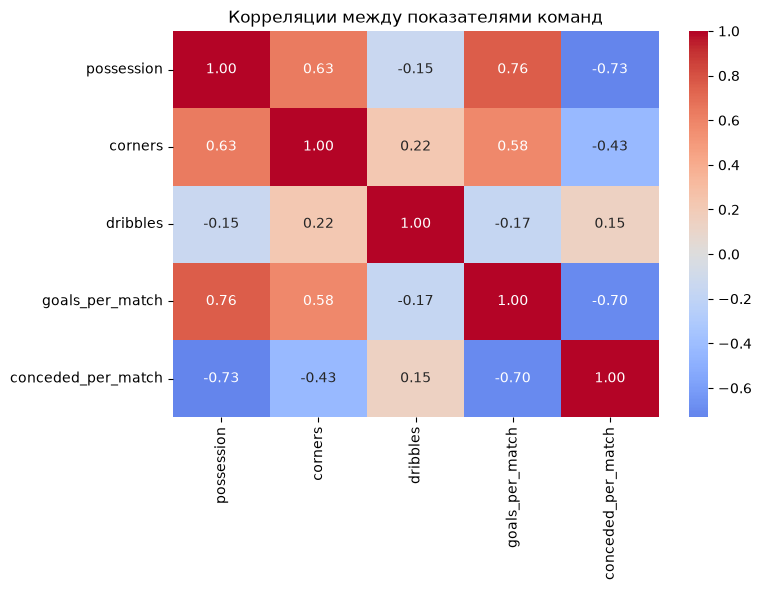

In [28]:
corr = team_analysis[
    ['possession', 'corners', 'dribbles',
     'goals_per_match', 'conceded_per_match']
].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляции между показателями команд')
plt.tight_layout()
plt.show()

Наиболее заметная связь наблюдается между владением мячом и результативностью (r = 0,76): команды с большим владением в среднем забивали больше. Владение также связано с меньшим количеством пропущенных голов (r = −0,73).

Количество угловых умеренно связано с владением (r = 0,63) и забитыми голами (r = 0,58). При этом обводки практически не связаны с другими показателями: их корреляции находятся в диапазоне от −0,17 до 0,22.

### Владение и очки

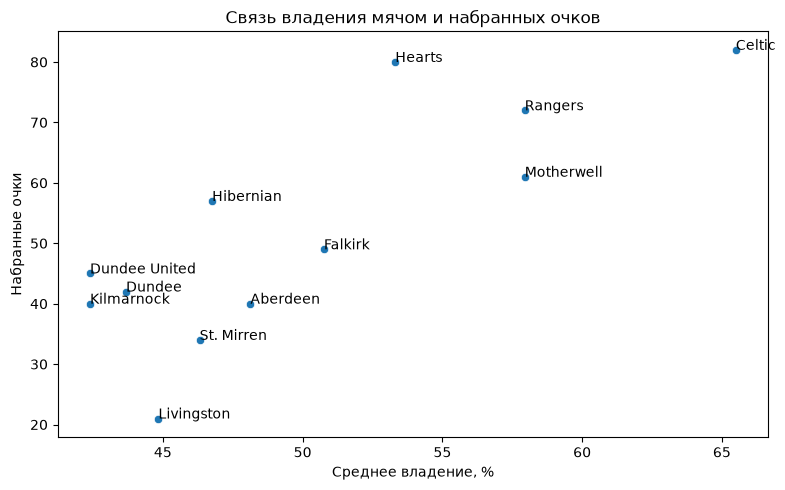

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=team_analysis, x='possession', y='points')

for _, row in team_analysis.iterrows():
    plt.text(row['possession'], row['points'], row['team_name'])

plt.xlabel('Среднее владение, %')
plt.ylabel('Набранные очки')
plt.title('Связь владения мячом и набранных очков')
plt.tight_layout()
plt.show()

Наиболее заметное отклонение от общей зависимости показывает **Hearts**: команда набрала 80 очков при среднем владении 53,3%, тогда как **Rangers** при более высоком владении (57,9%) набрали 72 очка. Это указывает на то, что одинаковый уровень контроля мяча не обязательно приводит к одинаковому результату.

**Hibernian** также выделяется относительно высокой результативностью при невысоком владении — 57 очков при 46,8%. В нижней части таблицы **Dundee United** имеет примерно такое же владение, как Kilmarnock (42,4%), но набрал на 5 очков больше.

В целом график показывает, что связь между владением и очками заметна, но отдельные команды существенно отклоняются от общей тенденции.

### Угловые и очки

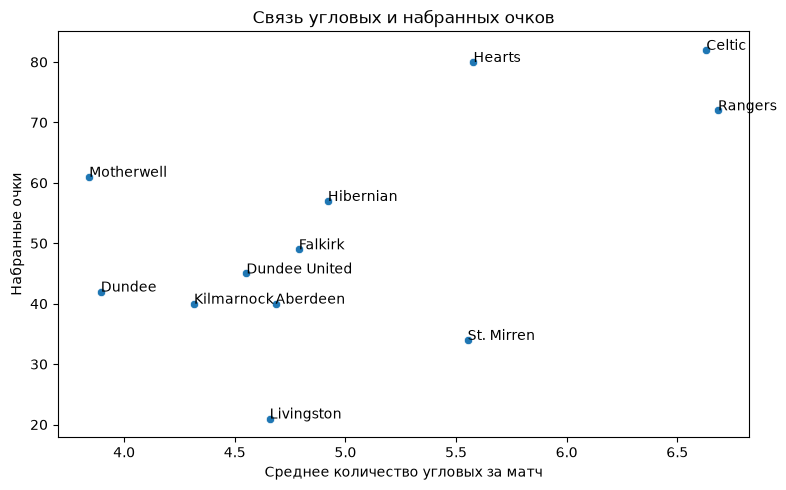

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=team_analysis, x='corners', y='points')

for _, row in team_analysis.iterrows():
    plt.text(row['corners'], row['points'], row['team_name'])

plt.xlabel('Среднее количество угловых за матч')
plt.ylabel('Набранные очки')
plt.title('Связь угловых и набранных очков')
plt.tight_layout()
plt.show()

Связь между количеством угловых и набранными очками выражена слабее, чем для владения мячом. При этом отдельные команды заметно отклоняются от общей тенденции.

**Motherwell** — наиболее яркий пример: команда имеет лишь 3,84 угловых за матч, но набрала 61 очко. Напротив, **St. Mirren** получает в среднем 5,55 угловых, но набрал только 34 очка.

Также выделяется **Hearts**: 5,58 угловых за матч и 80 очков, тогда как **Rangers** при более высоком показателе (6,68) набрали 72 очка.

Таким образом, количество угловых само по себе не объясняет результат команды: эффективность использования созданных эпизодов, вероятно, важнее их количества.

### Статистическая проверка

Для небольшой выборки из 12 команд проверим корреляции с помощью коэффициента Спирмена. Он позволяет оценить монотонную связь без требования нормального распределения показателей.

In [20]:
from scipy.stats import spearmanr

results = []

for metric in ['possession', 'corners', 'dribbles']:
    rho, p_value = spearmanr(team_analysis[metric], team_analysis['points'])
    results.append([metric, rho, p_value])

spearman = pd.DataFrame(results, columns=['metric', 'rho', 'p_value'])
spearman

,metric,rho,p_value
0,possession,0.753955,0.004617
1,corners,0.458845,0.133507
2,dribbles,-0.374782,0.230003


Для владения мячом обнаружена сильная положительная монотонная связь с набранными очками (**ρ = 0,75; p = 0,005**). Для количества угловых (**ρ = 0,46; p = 0,134**) и обводок (**ρ = −0,37; p = 0,230**) статистически значимой связи не обнаружено.

Таким образом, среди рассмотренных игровых показателей именно **владение мячом** имеет наиболее устойчивую связь с результатом команды в данном сезоне.

## 5. Домашние и гостевые матчи

Сравним показатели команд в домашних и гостевых матчах.

In [21]:
home_away = (
    team.groupby(['team_name', 'home_away'])
    .agg(
        points=('points', 'mean'),
        goals=('goals', 'mean'),
        goals_conceded=('opponent_goals', 'mean'),
        possession=('ball_possession', 'mean'),
        corners=('corners', 'mean')
    )
    .reset_index()
)

In [22]:
home_away.pivot(
    index='team_name',
    columns='home_away',
    values='points'
).sort_values('home', ascending=False)

home_away,away,home
team_name,,
Hearts,1.631579,2.578947
Celtic,1.894737,2.421053
Rangers,1.789474,2.000000
Motherwell,1.315789,1.894737
Dundee,0.578947,1.631579
Hibernian,1.421053,1.578947
Dundee United,0.894737,1.473684
Aberdeen,0.736842,1.368421
Kilmarnock,0.789474,1.315789


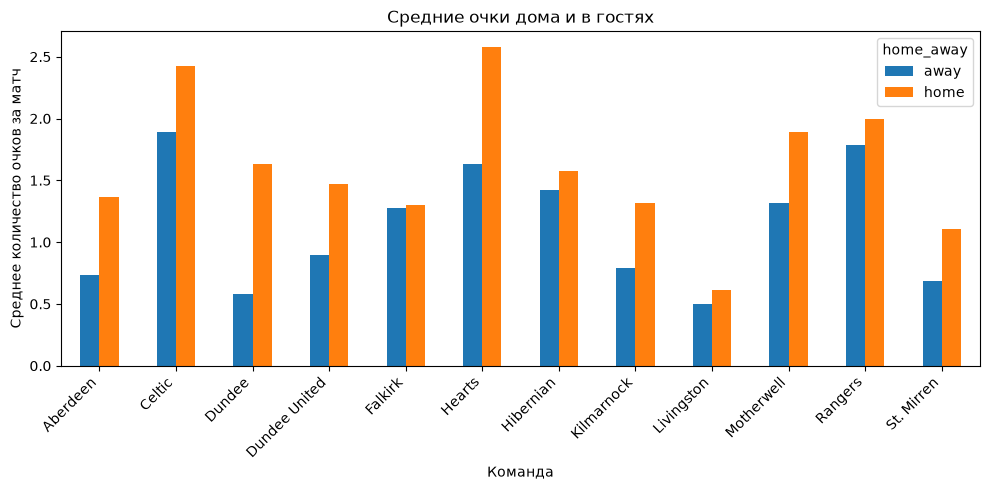

In [23]:
home_away_plot = home_away.pivot(
    index='team_name',
    columns='home_away',
    values='points'
)

home_away_plot.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Команда')
plt.ylabel('Среднее количество очков за матч')
plt.title('Средние очки дома и в гостях')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Для большинства команд характерно заметное преимущество по набранным очкам в домашних матчах. Особенно выделяется **Hearts**: в среднем команда набирала **2,58 очка дома против 1,63 в гостях**.

У **Celtic** также наблюдается существенная разница — **2,42 очка дома против 1,89 в гостях**. У **Rangers** разрыв меньше: **2,00 дома против 1,79 в гостях**.

Интересное исключение — **Falkirk**: показатели практически одинаковы (**1,30 дома и 1,28 в гостях**). В целом домашние матчи давали большинству команд заметное преимущество по набранным очкам, но его величина существенно различалась.

In [29]:
home_away.pivot(
    index='team_name',
    columns='home_away',
    values='goals'
).sort_values('home', ascending=False)

home_away,away,home
team_name,,
Celtic,1.578947,2.263158
Rangers,1.947368,2.052632
Hearts,1.578947,1.947368
Motherwell,1.421053,1.684211
Hibernian,1.368421,1.684211
Falkirk,0.944444,1.650000
Dundee,0.578947,1.631579
Aberdeen,0.631579,1.473684
Kilmarnock,1.157895,1.473684


Для большинства команд характерна более высокая результативность в домашних матчах. Наиболее заметна разница у Falkirk: 1,65 гола дома против 0,94 в гостях. У Celtic также существенный разрыв — 2,26 дома против 1,58 в гостях.

Исключением является Dundee United, которая в гостях забивала немного больше: 1,32 против 1,26 дома. У Rangers разница между домашней и гостевой результативностью минимальна — 2,05 против 1,95.

In [30]:
home_away.pivot(
    index='team_name',
    columns='home_away',
    values='goals_conceded'
).sort_values('home', ascending=False)

home_away,away,home
team_name,,
Livingston,1.950000,2.000000
Falkirk,1.555556,1.700000
Dundee,1.736842,1.473684
Kilmarnock,2.105263,1.473684
Aberdeen,1.684211,1.210526
Dundee United,2.000000,1.157895
St. Mirren,1.736842,1.157895
Rangers,1.157895,1.105263
Hibernian,1.315789,1.000000


Для большинства команд количество пропущенных голов дома ниже, чем в гостевых матчах. Особенно заметна разница у Kilmarnock: 1,47 пропущенного дома против 2,11 в гостях, и у Dundee United: 1,16 против 2,00.

У Livingston показатели практически одинаковы — 2,00 дома и 1,95 в гостях. У Falkirk наблюдается обратная картина: команда пропускала немного больше дома — 1,70 против 1,56 в гостях.

Вывод

Для большинства команд домашние матчи давали преимущество сразу по трём показателям: команды набирали больше очков, чаще забивали и реже пропускали. При этом выраженность домашнего преимущества заметно различалась: например, у Hearts оно особенно сильно проявлялось в набранных очках, у Falkirk — в результативности, а у Kilmarnock — в количестве пропущенных голов. При этом встречались и исключения, такие как Dundee United, которая немного больше забивала в гостях.

## 6. Дисциплина

Отдельно посмотрим на жёлтые и красные карточки. Сначала сравним их распределение между командами, а затем — домашние и гостевые матчи.

In [24]:
cards_by_team = (
    team.groupby('team_name')
    .agg(
        yellowcards=('yellowcards', 'sum'),
        redcards=('redcards', 'sum')
    )
    .sort_values('yellowcards', ascending=False)
)

cards_by_team

,yellowcards,redcards
team_name,,
Livingston,91,4
Aberdeen,88,5
Kilmarnock,86,5
Dundee United,84,4
Falkirk,83,1
Celtic,78,2
Hibernian,77,5
St. Mirren,74,4
Rangers,73,1


In [25]:
cards_home_away = (
    team.groupby('home_away')
    .agg(
        yellowcards=('yellowcards', 'mean'),
        redcards=('redcards', 'mean')
    )
)

cards_home_away

,yellowcards,redcards
home_away,,
away,2.197368,0.078947
home,1.837719,0.105263


По количеству карточек команды заметно различаются. **Livingston** получил больше всего жёлтых (91) и красных карточек (4), тогда как **Dundee** — меньше всего жёлтых (53).

В среднем в гостевых матчах команды получали больше жёлтых карточек, чем в домашних (**2,20 против 1,84**). При этом красные карточки, наоборот, чаще фиксировались в домашних матчах (**0,11 против 0,08**).

## 7. Выводы

По итогам анализа сезона 2025/2026 наиболее интересным результатом стала связь **владения мячом с качеством игры команды**. Команды с большим владением в среднем чаще забивали (`r = 0,76`) и меньше пропускали (`r = −0,73`). Связь владения с набранными очками также оказалась статистически значимой (`ρ = 0,75; p = 0,005`).

Интересный результат получился и для **обводок**: их количество практически не связано ни с результативностью, ни с количеством пропущенных голов. Для **угловых** связь с очками заметно слабее, чем для владения, и статистически значимой в данном сезоне она не оказалась.

Отдельно проявился фактор домашнего поля. Для большинства команд дома одновременно наблюдались **более высокая результативность, меньшее количество пропущенных голов и большее количество набранных очков**. Однако выраженность этого преимущества сильно различалась между командами: например, Hearts набирали 2,58 очка дома против 1,63 в гостях, а у Falkirk разница практически отсутствовала — 1,30 против 1,28.

В итоге наиболее заметными особенностями сезона стали **связь владения с результативностью, выраженное домашнее преимущество большинства команд и отсутствие очевидной связи между количеством индивидуальных обводок и командным результатом**. 